주사위 4개를 던질 때 적어도 6이 두 개 나올 확률

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)  # 항상 같은 숫자가 나옵니다(재현 가능해야 함)

# -----------------------------
# 1. 시뮬레이션 설정
# -----------------------------
n_trials = 100000  # 실험 횟수 (충분히 크게)
n_dice = 4         # 주사위 개수

# -----------------------------
# 2. 주사위 던지기 시뮬레이션 : = “주사위를 여러 번 던진 결과를 표 형태로 한 번에 생성”
# -----------------------------
# 각 행: 1번 실험  -- 100,000 행 : 실험횟수
# 각 열: 각 주사위 결과 -- 주사위 개수 4개
# 벡터화
dice = np.random.randint(1, 7, size=(n_trials, n_dice))  # 1~6(주사위값)=1이상 7미만 정수 생성


# -----------------------------
# 3. "6이 나왔는지"를 0/1로 변환
# -----------------------------
# 6이면 1, 아니면 0
is_six = (dice == 6).astype(int)

# -----------------------------
# 4. 각 실험에서 6의 개수 --> 3이 되어야 6이 나온 개수를 셀 수 있다.
# -----------------------------
num_six = is_six.sum(axis=1)

# -----------------------------
# 5. 우리가 구하는 확률
# -----------------------------
prob_at_least_2 = np.mean(num_six >= 2)

print("적어도 2개 6이 나올 확률:", prob_at_least_2)

# -----------------------------
# 6. 주변확률 (Marginal Distribution)
# -----------------------------
# X = "6의 개수"의 분포
marginal_dist = pd.Series(num_six).value_counts(normalize=True).sort_index()

print("\n[주변확률분포 P(X=k)]")
print(marginal_dist)

# -----------------------------
# 7. 공분산 & 상관계수
# -----------------------------
# 각 주사위가 서로 독립인지 확인
df = pd.DataFrame(is_six, columns=["D1", "D2", "D3", "D4"])

cov_matrix = df.cov()
corr_matrix = df.corr()

print("\n[공분산 행렬]")
print(cov_matrix)

print("\n[상관계수 행렬]")
print(corr_matrix)

적어도 2개 6이 나올 확률: 0.13227

[주변확률분포 P(X=k)]
0    0.48499
1    0.38274
2    0.11582
3    0.01575
4    0.00070
Name: proportion, dtype: float64

[공분산 행렬]
          D1        D2        D3        D4
D1  0.139332 -0.000081  0.000345  0.000416
D2 -0.000081  0.138064 -0.000021  0.000543
D3  0.000345 -0.000021  0.137837  0.000519
D4  0.000416  0.000543  0.000519  0.138832

[상관계수 행렬]
          D1        D2        D3        D4
D1  1.000000 -0.000587  0.002493  0.002992
D2 -0.000587  1.000000 -0.000151  0.003920
D3  0.002493 -0.000151  1.000000  0.003754
D4  0.002992  0.003920  0.003754  1.000000


 한 카페에는 고객이 평균적으로 4분마다 1명씩 도착한다. 고객 도착 간격은 지수분포를 따른다고 가정할 때,하루 동안 500명의 고객이 도착했다고 가정하고, 고객 간 도착 시간 500개를 시뮬레이션을 파이썬의 Pandas의 random.expotential()로 구현

평균 도착 간격: 4.017236716473617
총 소요 시간: 2008.618358236808

[상위 5개 데이터]
   inter_arrival_time  arrival_time
0            1.877072      1.877072
1           12.040486     13.917558
2            5.266983     19.184541
3            3.651770     22.836311
4            0.678499     23.514811


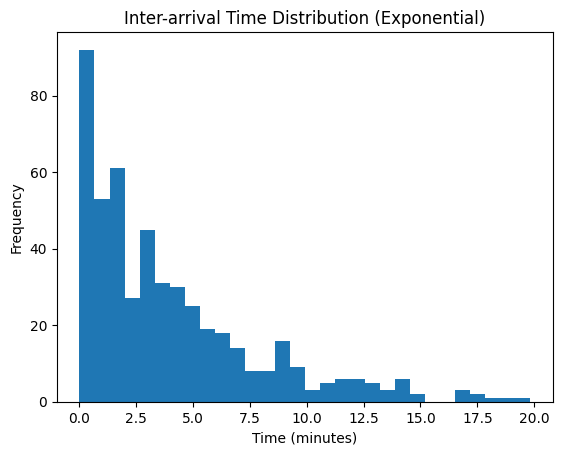

In [2]:
# ============================================
# 0. 라이브러리 로드
# ============================================
import numpy as np
import pandas as pd

# ============================================
# 1. 재현성 확보 (매번 같은 결과)
# ============================================
np.random.seed(42)

# ============================================
# 2. 문제 설정
# ============================================
# 평균 4분마다 고객 1명 도착
# → 지수분포에서 평균 = scale = 4
mean_interval = 4  # 분

# 하루 동안 고객 수 (문제에서 500명 가정)
n_customers = 500

# ============================================
# 3. 지수분포에서 도착 간격 생성
# ============================================
# np.random.exponential(scale, size)
# - scale = 평균 (여기서는 4분)
# - size = 생성할 샘플 수 (500개)
inter_arrival_times = np.random.exponential(
    scale=mean_interval,
    size=n_customers
)

# ============================================
# 4. Pandas DataFrame으로 변환
# ============================================
df = pd.DataFrame({
    "inter_arrival_time": inter_arrival_times
})

# ============================================
# 5. 실제 도착 시각 계산 (누적합)
# ============================================
# 고객은 순차적으로 도착하므로
# "도착 간격"을 계속 더하면 "도착 시각"이 됨
df["arrival_time"] = df["inter_arrival_time"].cumsum()

# ============================================
# 6. 기본 통계 확인
# ============================================
print("평균 도착 간격:", df["inter_arrival_time"].mean())
print("총 소요 시간:", df["arrival_time"].iloc[-1])

# ============================================
# 7. 일부 데이터 확인
# ============================================
print("\n[상위 5개 데이터]")
print(df.head())

# ============================================
# 8. 분포 확인 (히스토그램)
# ============================================
import matplotlib.pyplot as plt

plt.hist(df["inter_arrival_time"], bins=30)
plt.title("Inter-arrival Time Distribution (Exponential)")
plt.xlabel("Time (minutes)")
plt.ylabel("Frequency")
plt.show()

확률변수 X가 U(0,10)를 따른다고 하자. 다음 확률을 구하라. (1) P(X<3) (2) P(X>6) (3) P(3<X<8)

In [2]:
import numpy as np

# ============================================
# 1. 재현성 확보
# ============================================
np.random.seed(42)

# ============================================
# 2. 샘플 생성
# ============================================
# Uniform(0,10)에서 100만 개 샘플 생성
# → 실제 확률을 근사하기 위해 충분히 큰 수 사용
n_samples = 1000000

X = np.random.uniform(0, 10, size=n_samples)

# ============================================
# 3. 확률 계산
# ============================================

# (1) P(X < 3)
# 조건을 만족하면 True → 1, 아니면 0 → 평균 = 확률
p1 = np.mean(X < 3)

# (2) P(X > 6)
p2 = np.mean(X > 6)

# (3) P(3 < X < 8)
p3 = np.mean((X > 3) & (X < 8))

# ============================================
# 4. 결과 출력
# ============================================
print("P(X < 3) ≈", p1)
print("P(X > 6) ≈", p2)
print("P(3 < X < 8) ≈", p3)

P(X < 3) ≈ 0.29952
P(X > 6) ≈ 0.400526
P(3 < X < 8) ≈ 0.500228


확률변수 X를 주사위 한 개를 던져서 나온 결과라 하자. 1이 나오면 X=1이고, 그 외의 숫자가 나오면 X=0 이다. X의 확률분포 P(X=x)를 베르누이 분포에 따라 구함

In [3]:
import numpy as np
import pandas as pd

# ============================================
# [1] 베르누이 분포(Bernoulli Distribution)란?
# ============================================
# - 결과가 딱 2개만 있는 확률분포 (0 또는 1)
# - 예:
#     성공(1) / 실패(0)
#     구매(1) / 비구매(0)
#     클릭(1) / 비클릭(0)
#
# - 확률변수 X:
#     X = 1 (성공) with probability p
#     X = 0 (실패) with probability 1-p
#
# - 확률질량함수(PMF):
#     P(X = x) = p^x * (1-p)^(1-x),  x ∈ {0,1}
#
# - 평균:
#     E[X] = p
#
# - 분산:
#     Var(X) = p(1-p)
#
# --------------------------------------------
# 이 문제에서의 해석:
# --------------------------------------------
# - 주사위 1개 던짐
# - "1이 나오면 성공(1)"
# - "나머지는 실패(0)"
#
# → 성공확률 p = 1/6
# → X ~ Bernoulli(p = 1/6)
# ============================================


# ============================================
# [2] 시뮬레이션 설정
# ============================================
np.random.seed(42)  # 재현성 확보
n_trials = 100000   # 실험 횟수 (충분히 크게)


# ============================================
# [3] 주사위 시뮬레이션
# ============================================
# 1~6 사이 정수 생성 (주사위)
dice = np.random.randint(1, 7, size=n_trials)


# ============================================
# [4] 베르누이 변수 생성
# ============================================
# 조건:
# - 1이 나오면 → 1 (성공)
# - 그 외 → 0 (실패)
#
# (dice == 1) → True/False
# .astype(int) → 1/0으로 변환
X = (dice == 1).astype(int)


# ============================================
# [5] 확률분포 P(X=x) 계산
# ============================================
# value_counts(normalize=True)
# → 각 값의 비율 = 확률
prob_dist = pd.Series(X).value_counts(normalize=True).sort_index()

print("[확률분포 P(X=x)]")
print(prob_dist)


# ============================================
# [6] 이론값 비교
# ============================================
# 이론적으로:
# P(X=1) = 1/6
# P(X=0) = 5/6
print("\n[이론값]")
print("P(X=1) =", 1/6)
print("P(X=0) =", 5/6)


# ============================================
# [7] 평균과 분산 확인 (베르누이 성질 검증)
# ============================================
print("\n[통계값]")
print("표본 평균 (≈ p):", np.mean(X))
print("표본 분산 (≈ p(1-p)):", np.var(X))

[확률분포 P(X=x)]
0    0.83408
1    0.16592
Name: proportion, dtype: float64

[이론값]
P(X=1) = 0.16666666666666666
P(X=0) = 0.8333333333333334

[통계값]
표본 평균 (≈ p): 0.16592
표본 분산 (≈ p(1-p)): 0.13839055359999997


(1) 확률변수 X가 표준정규분포 N(0,1)을 따를 때 P(-3<=X<=3)을 구하여라. (2) 확률변수 X가 N(2,25)을 따를 때 P(-3<=X<=8)을 구하여라.

In [ ]:
import numpy as np
from scipy.stats import norm

# ============================================
# [1] 문제 (1): 표준정규분포 N(0,1)
# ============================================

# norm.cdf(x) = x보다 작을 확률
# 즉, "왼쪽 면적"

# P(-3 <= X <= 3)
# = P(X <= 3) - P(X <= -3)

p1 = norm.cdf(3) - norm.cdf(-3)

print("문제 (1) 결과:", p1)


# ============================================
# [2] 문제 (2): N(2,25)
# ============================================

# 평균(mu) = 2
mu = 2

# 분산 = 25 → 표준편차(sigma) = 5
sigma = 5

# 우리가 구하려는 것:
# P(-3 <= X <= 8)

# --------------------------------------------
# [중요] 표준화 (Z로 변환)
# --------------------------------------------
# Z = (X - 평균) / 표준편차

# X = -3 → Z 값
z1 = (-3 - mu) / sigma

# X = 8 → Z 값
z2 = (8 - mu) / sigma

# 이제 표준정규분포에서 계산
p2 = norm.cdf(z2) - norm.cdf(z1)

print("문제 (2) 결과:", p2)

#(1) 👉 거의 100% 👉 “±3 범위 안에 거의 다 있음” (2) 👉 약 72.6%
#--> 👉 “정규분포 문제는 결국 표준화해서 표준정규분포로 바꾸면 쉽게 풀린다”


문제 (1) 결과: 0.9973002039367398
문제 (2) 결과: 0.7262750758468347


이항분포와 포아송분포를 활용한 예시를 찾아 X를 50,000회 시뮬레이션을 수행하는 파이썬 프로그램
👉 “웹 서비스에서 사용자 1명이 광고를 클릭할 확률이 매우 낮다”

사용자 수 n=1000명
클릭 확률 p=0.002 (0.2%)

👉 관심 변수 X: “총 클릭 수”

정확한 모델 → 이항분포
근사 모델 → 포아송분포 (λ = np = 2)

[이항분포 일부]
0    0.13614
1    0.27086
2    0.27238
3    0.17872
4    0.09024
Name: proportion, dtype: float64

[포아송분포 일부]
0    0.13290
1    0.27354
2    0.27006
3    0.17846
4    0.09232
Name: proportion, dtype: float64

[평균 비교]
이항 평균: 1.99368
포아송 평균: 2.0048


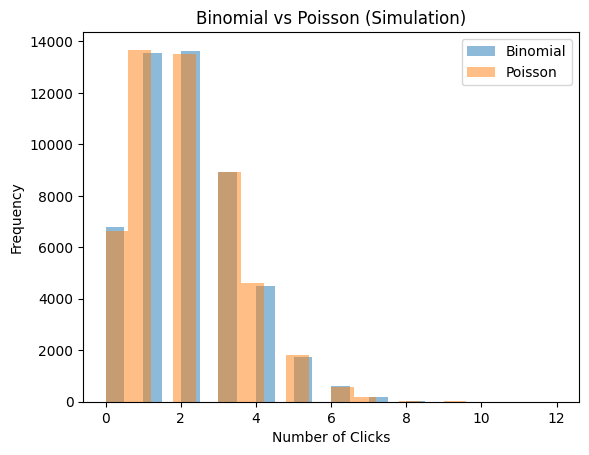

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# [1] 재현성 확보
# ============================================
np.random.seed(42)

# ============================================
# [2] 문제 설정 (실무 상황)
# ============================================
# n = 사용자 수
n = 1000

# p = 한 사람이 클릭할 확률 (매우 작음)
p = 0.002

# 포아송 분포의 λ = n * p
lam = n * p   # = 2

# 시뮬레이션 횟수
n_sim = 50000


# ============================================
# [3] 이항분포 시뮬레이션
# ============================================
# np.random.binomial(n, p, size)
# → n번 시행 중 성공 횟수
binomial_samples = np.random.binomial(n=n, p=p, size=n_sim)


# ============================================
# [4] 포아송분포 시뮬레이션
# ============================================
# np.random.poisson(lam, size)
# → 단위 시간 내 사건 발생 횟수
poisson_samples = np.random.poisson(lam=lam, size=n_sim)


# ============================================
# [5] 결과 비교 (확률분포 형태)
# ============================================
# value_counts(normalize=True) → 확률
binom_dist = pd.Series(binomial_samples).value_counts(normalize=True).sort_index()
poisson_dist = pd.Series(poisson_samples).value_counts(normalize=True).sort_index()

print("[이항분포 일부]")
print(binom_dist.head())

print("\n[포아송분포 일부]")
print(poisson_dist.head())


# ============================================
# [6] 평균 비교
# ============================================
print("\n[평균 비교]")
print("이항 평균:", np.mean(binomial_samples))
print("포아송 평균:", np.mean(poisson_samples))


# ============================================
# [7] 시각화 비교
# ============================================
plt.hist(binomial_samples, bins=20, alpha=0.5, label="Binomial")
plt.hist(poisson_samples, bins=20, alpha=0.5, label="Poisson")

plt.legend()
plt.title("Binomial vs Poisson (Simulation)")
plt.xlabel("Number of Clicks")
plt.ylabel("Frequency")
plt.show()

#이항분포 : “n번 시도 중 성공 횟수” 
#  각 사용자가 클릭할지 말지 / 독립적인 0/1 실험
#포아송분포 : “단위 시간 동안 사건 발생 횟수”
#   클릭이 시간 흐름 속에서 발생한다고 보는 관점

두 확률변수 X, Y의 결합밀도함수가 다음과 같이 주어져 있다고 하자. f(x,y) = x+y, 0<x<1, 0<y<1 X와 Y의 주변밀도함수를 각각 구하라
👉 “결합밀도 = 두 변수가 동시에 가질 확률의 ‘지도’”
👉 “주변밀도 = 하나만 보고 싶을 때 나머지를 ‘더해서 제거’”

In [ ]:
import sympy as sp

# ============================================
# [1] 변수 정의
# ============================================
# x, y를 수학 변수처럼 사용하기 위해 sympy 사용
x, y = sp.symbols('x y')

# ============================================
# [2] 결합밀도함수 정의
# ============================================
# f(x,y) = x + y
f = x + y


# ============================================
# [3] X의 주변밀도 f_X(x) 계산
# ============================================
# 개념:
# Y를 없애기 위해 Y에 대해 적분
# 범위: 0 ~ 1

f_X = sp.integrate(f, (y, 0, 1))

print("[X의 주변밀도 f_X(x)]")
print(f_X)


# ============================================
# [4] Y의 주변밀도 f_Y(y) 계산
# ============================================
# 개념:
# X를 없애기 위해 X에 대해 적분

f_Y = sp.integrate(f, (x, 0, 1))

print("\n[Y의 주변밀도 f_Y(y)]")
print(f_Y)


# ============================================
# [5] 결과 확인
# ============================================
# 우리가 기대하는 결과:
# f_X(x) = x + 1/2
# f_Y(y) = y + 1/2

#👉 결합밀도는 “2차원 정보”
#👉 주변밀도는 “한 축만 남기고 나머지 제거”, 👉 “주변밀도는 결합밀도에서 다른 변수를 적분해서 제거한 것”

[X의 주변밀도 f_X(x)]
x + 1/2

[Y의 주변밀도 f_Y(y)]
y + 1/2
